In [5]:
# Install PyTorch and other required packages
import sys

# Install PyTorch (CPU version for compatibility)
print("Installing PyTorch...")
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu -q

# Install depthcharge and other dependencies
print("Installing depthcharge and dependencies...")
!{sys.executable} -m pip install depthcharge-ms -q
!{sys.executable} -m pip install pyteomics spectrum_utils -q

print("✓ All packages installed successfully!")

Installing PyTorch...
Installing depthcharge and dependencies...
✓ All packages installed successfully!


## 0. Install Required Packages

# Transformer Model Embedding Visualization

This notebook creates the distance distribution plot similar to Extended Data Fig. 3 from Bittremieux et al.

It shows:
- Distribution of embedding distances for positive pairs (similar spectra)
- Distribution of embedding distances for negative pairs (dissimilar spectra)
- FDR threshold line
- ROC curve and AUC score

In [1]:
import sys
import os

# Add GLEAMS directory to path for proper imports
gleams_dir = os.path.abspath(os.path.join(os.getcwd(), '../..'))
if gleams_dir not in sys.path:
    sys.path.insert(0, gleams_dir)

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Import visualization functions from the transformer_encoder package
from gleams.transformer_encoder.visualization import (
    compute_embedding_distances,
    plot_embedding_distance_distribution,
    plot_roc_curve,
    print_statistics,
    compute_fdr_threshold
)
from gleams.transformer_encoder.dataloader import create_dataloader
from gleams.transformer_encoder.dataset import SpectraDataset
from gleams.transformer_encoder import config

%matplotlib inline
plt.style.use('default')

/home/saartje/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration

In [25]:
# Paths (relative to GLEAMS directory)
MODEL_PATH = '../../models/best_model.pt'  # or 'final_model.pt'
TEST_METADATA = '../../data/test_metadata.parquet'
TEST_PAIRS_POS = '../../data/test_metadata_pairs_pos_2.npy'
TEST_PAIRS_NEG = '../../data/test_metadata_pairs_neg_2.npy'
MGF_FILE = '../../data/massivekb_82c0124b.mgf'

# Analysis parameters
SAMPLE_PAIRS = 20000  # Sample pairs for faster computation (set to None for all)
FDR = 0.01  # 1% false discovery rate
BATCH_SIZE = 128

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [19]:
# Create results directory if it doesn't exist
import os
results_dir = '../../results'
os.makedirs(results_dir, exist_ok=True)
print(f"Results directory ready: {os.path.abspath(results_dir)}")

Results directory ready: /home/saartje/Desktop/Research/GLEAMS/results


## 2. Load Data

In [26]:
# Load metadata
print("Loading test metadata...")
test_metadata = pd.read_parquet(TEST_METADATA)
print(f"Loaded {len(test_metadata):,} spectra")

# Load pairs
print("\nLoading test pairs...")
test_pos_pairs = np.load(TEST_PAIRS_POS).astype(int)
test_neg_pairs = np.load(TEST_PAIRS_NEG).astype(int)
print(f"Positive pairs: {len(test_pos_pairs):,}")
print(f"Negative pairs: {len(test_neg_pairs):,}")

Loading test metadata...
Loaded 200,000 spectra

Loading test pairs...
Positive pairs: 107,229
Negative pairs: 713,210


In [27]:
# Sample pairs if needed (for faster computation)
if SAMPLE_PAIRS and SAMPLE_PAIRS < len(test_pos_pairs) + len(test_neg_pairs):
    print(f"\nSampling {SAMPLE_PAIRS:,} random pairs...")
    n_pos_sample = min(SAMPLE_PAIRS // 2, len(test_pos_pairs))
    n_neg_sample = min(SAMPLE_PAIRS // 2, len(test_neg_pairs))
    
    np.random.seed(42)  # For reproducibility
    pos_indices = np.random.choice(len(test_pos_pairs), n_pos_sample, replace=False)
    neg_indices = np.random.choice(len(test_neg_pairs), n_neg_sample, replace=False)
    
    test_pos_pairs = test_pos_pairs[pos_indices]
    test_neg_pairs = test_neg_pairs[neg_indices]
    
    print(f"Sampled positive pairs: {len(test_pos_pairs):,}")
    print(f"Sampled negative pairs: {len(test_neg_pairs):,}")


Sampling 20,000 random pairs...
Sampled positive pairs: 10,000
Sampled negative pairs: 10,000


## 3. Create DataLoader

In [28]:
# Create dataset
print("Creating dataset...")

# Extract unique scan numbers from pairs to avoid loading 30 million spectra
print("Extracting unique scan numbers from pairs...")
# Pairs contain indices into the metadata DataFrame
all_pair_indices = np.unique(np.concatenate([
    test_pos_pairs.flatten(),
    test_neg_pairs.flatten()
]))

# Get scan numbers from metadata for these indices
scan_nrs = test_metadata.iloc[all_pair_indices]['scan'].tolist()
print(f"Loading {len(scan_nrs):,} unique spectra (out of {len(test_metadata):,} total)")

# Create a mapping from old indices to new indices
# old_idx -> new_idx (position in the subset dataset)
old_to_new_idx = {old_idx: new_idx for new_idx, old_idx in enumerate(all_pair_indices)}

# Remap pairs to use new indices
print("Remapping pair indices to subset dataset...")
remapped_pos_pairs = np.array([[old_to_new_idx[i], old_to_new_idx[j]] 
                                for i, j in test_pos_pairs])
remapped_neg_pairs = np.array([[old_to_new_idx[i], old_to_new_idx[j]] 
                                for i, j in test_neg_pairs])

print(f"Remapped {len(remapped_pos_pairs):,} positive pairs")
print(f"Remapped {len(remapped_neg_pairs):,} negative pairs")

# Load only the spectra we need
test_dataset = SpectraDataset(
    mgf_path=MGF_FILE,
    scan_nrs=scan_nrs  # Load only spectra needed for our pairs
)

Creating dataset...
Extracting unique scan numbers from pairs...
Loading 33,628 unique spectra (out of 200,000 total)
Remapping pair indices to subset dataset...
Remapped 10,000 positive pairs
Remapped 10,000 negative pairs
Loading spectra from ../../data/massivekb_82c0124b.mgf...
✓ Loaded 33,628 spectra
✓ Loaded 33,628 spectra with max 1517 peaks in 6.0 min


In [29]:
# Create dataloader with remapped pairs
test_dataloader = create_dataloader(
    test_dataset,
    remapped_pos_pairs,  # Use remapped indices
    remapped_neg_pairs,  # Use remapped indices
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print(f"DataLoader ready with {len(test_dataloader):,} batches")

Total pairs: 20,000
Creating DataLoader with 20,000 total pairs, batch_size=128
Expected batches per epoch: 156
DataLoader ready with 157 batches


## 4. Load Model and Compute Distances

In [30]:
# Load trained model
print(f"Loading model from {MODEL_PATH}...")
checkpoint = torch.load(MODEL_PATH, map_location=device)

# Check what was saved
if isinstance(checkpoint, dict):
    print("Checkpoint is a dictionary with keys:", checkpoint.keys())
    
    # Extract hyperparameters
    if 'hyperparameters' in checkpoint:
        hparams = checkpoint['hyperparameters']
        print("\nModel hyperparameters:")
        for key, value in hparams.items():
            print(f"  {key}: {value}")
    else:
        # Use default config values if not in checkpoint
        print("\nUsing default hyperparameters from config")
        hparams = {
            'dim_model': config.dim_model,
            'n_layers': config.n_layers,
            'n_head': config.n_head,
            'dim_feedforward': config.dim_feedforward,
            'dropout': config.dropout,
        }
    
    # Import model class
    from gleams.transformer_encoder.models import CustomSpectrumTransformerEncoder
    
    # Instantiate model with hyperparameters
    encoder = CustomSpectrumTransformerEncoder(
        d_model=hparams['dim_model'],
        nhead=hparams['n_head'],
        dim_feedforward=hparams['dim_feedforward'],
        n_layers=hparams['n_layers'],
        dropout=hparams.get('dropout', 0.0),
    )
    
    # Load state dict
    encoder.load_state_dict(checkpoint['model_state_dict'])
    encoder.to(device)
    encoder.eval()
    print("\n✓ Model loaded successfully from checkpoint!")
    
else:
    print("Checkpoint is a model object")
    encoder = checkpoint
    encoder.to(device)
    encoder.eval()
    print("✓ Model loaded successfully!")

Loading model from ../../models/best_model.pt...
Checkpoint is a dictionary with keys: dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'train_loss', 'val_loss', 'hyperparameters'])

Model hyperparameters:
  dim_model: 256
  n_layers: 2
  n_head: 4
  dim_feedforward: 512
  dropout: 0.1
  margin: 1.0

✓ Model loaded successfully from checkpoint!


In [31]:
# Compute embedding distances
print("Computing embedding distances...")
positive_distances, negative_distances = compute_embedding_distances(
    encoder,
    test_dataloader,
    device,
    max_pairs=None  # Process all pairs in dataloader
)

print(f"\nComputed distances for:")
print(f"  Positive pairs: {len(positive_distances):,}")
print(f"  Negative pairs: {len(negative_distances):,}")

Computing embedding distances...


/home/saartje/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/home/saartje/miniconda3/lib/python3.13/site-packages/lance/__init__.py:292: UserWarning: lance is not fork-safe. If you are using multiprocessing, use spawn or forkserver instead.
  warnings.warn(
/home/saartje/miniconda3/lib/python3.13/site-packages/lance/__init__.py:292: UserWarning: lance is not fork-safe. If you are using multiprocessing, use spawn or forkserver instead.
  warnings.warn(



Computed distances for:
  Positive pairs: 10,000
  Negative pairs: 10,000


## 5. Statistics

In [32]:
# Print detailed statistics
print_statistics(positive_distances, negative_distances)


EMBEDDING DISTANCE STATISTICS

Positive Pairs (should be LOW distances):
  Count:   10,000
  Mean:    0.4275
  Median:  0.3955
  Std:     0.2246
  Min:     0.1331
  Max:     2.6245
  25th:    0.3774
  75th:    0.4132

Negative Pairs (should be HIGH distances):
  Count:   10,000
  Mean:    0.4286
  Median:  0.3960
  Std:     0.2279
  Min:     0.0616
  Max:     2.5128
  25th:    0.3777
  75th:    0.4133

Separation:
  Gap between means: 0.0011
  Ratio (neg/pos):   1.00x

Overlap region: [0.0616, 2.6245]
  Positive pairs in overlap: 10,000 (100.00%)
  Negative pairs in overlap: 10,000 (100.00%)



In [38]:
# Check 1: Verify checkpoint information
print("Checkpoint Information:")
print(f"  Epoch: {checkpoint.get('epoch', 'unknown')}")
print(f"  Train Loss: {checkpoint.get('train_loss', 'unknown')}")
print(f"  Val Loss: {checkpoint.get('val_loss', 'unknown')}")
print(f"  Margin: {checkpoint.get('hyperparameters', {}).get('margin', 'unknown')}")

# Check 2: Sample a few embeddings to see if they're diverse
print("\n" + "="*60)
print("Embedding Diversity Check")
print("="*60)

# Get first batch
sample_batch = next(iter(test_dataloader))
(mz1, int1, pepmass1, charge1), (mz2, int2, pepmass2, charge2), labels = sample_batch

mz1, int1, pepmass1, charge1 = mz1.to(device), int1.to(device), pepmass1.to(device), charge1.to(device)
mz2, int2, pepmass2, charge2 = mz2.to(device), int2.to(device), pepmass2.to(device), charge2.to(device)

with torch.no_grad():
    emb1_full, _ = encoder(mz1, int1, pepmass=pepmass1, charge=charge1)
    emb2_full, _ = encoder(mz2, int2, pepmass=pepmass2, charge=charge2)
    
    emb1 = emb1_full[:, 0, :]
    emb2 = emb2_full[:, 0, :]
    
    # Check statistics
    print(f"\nEmbedding 1 shape: {emb1.shape}")
    print(f"Embedding 1 stats:")
    print(f"  Mean: {emb1.mean():.6f}")
    print(f"  Std: {emb1.std():.6f}")
    print(f"  Min: {emb1.min():.6f}")
    print(f"  Max: {emb1.max():.6f}")
    
    print(f"\nEmbedding 2 shape: {emb2.shape}")
    print(f"Embedding 2 stats:")
    print(f"  Mean: {emb2.mean():.6f}")
    print(f"  Std: {emb2.std():.6f}")
    print(f"  Min: {emb2.min():.6f}")
    print(f"  Max: {emb2.max():.6f}")
    
    # Compute distances for sample
    distances = torch.nn.functional.pairwise_distance(emb1, emb2).cpu().numpy()
    labels_np = labels.numpy()
    
    pos_dists = distances[labels_np == 1]
    neg_dists = distances[labels_np == 0]
    
    print(f"\nSample batch distances:")
    print(f"  Positive pairs (n={len(pos_dists)}): mean={pos_dists.mean():.4f}, std={pos_dists.std():.4f}")
    print(f"  Negative pairs (n={len(neg_dists)}): mean={neg_dists.mean():.4f}, std={neg_dists.std():.4f}")
    
    # Check if embeddings are collapsed
    emb_norm1 = torch.nn.functional.normalize(emb1, dim=1)
    emb_norm2 = torch.nn.functional.normalize(emb2, dim=1)
    cosine_sim = (emb_norm1 * emb_norm2).sum(dim=1).cpu().numpy()
    
    print(f"\nCosine similarity in batch:")
    print(f"  Positive pairs: mean={cosine_sim[labels_np == 1].mean():.4f}")
    print(f"  Negative pairs: mean={cosine_sim[labels_np == 0].mean():.4f}")
    print(f"  (Higher cosine = more similar, should be high for pos, low for neg)")
    
    # Check embedding norm
    norms1 = torch.norm(emb1, dim=1).cpu().numpy()
    norms2 = torch.norm(emb2, dim=1).cpu().numpy()
    print(f"\nEmbedding norms:")
    print(f"  Batch 1: mean={norms1.mean():.4f}, std={norms1.std():.4f}")
    print(f"  Batch 2: mean={norms2.mean():.4f}, std={norms2.std():.4f}")

Checkpoint Information:
  Epoch: 2
  Train Loss: 0.3934158717978672
  Val Loss: 0.3812717736338655
  Margin: 1.0

Embedding Diversity Check


Checkpoint Information:
  Epoch: 2
  Train Loss: 0.3934158717978672
  Val Loss: 0.3812717736338655
  Margin: 1.0

Embedding Diversity Check


/home/saartje/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/home/saartje/miniconda3/lib/python3.13/site-packages/lance/__init__.py:292: UserWarning: lance is not fork-safe. If you are using multiprocessing, use spawn or forkserver instead.
  warnings.warn(
/home/saartje/miniconda3/lib/python3.13/site-packages/lance/__init__.py:292: UserWarning: lance is not fork-safe. If you are using multiprocessing, use spawn or forkserver instead.
  warnings.warn(


Checkpoint Information:
  Epoch: 2
  Train Loss: 0.3934158717978672
  Val Loss: 0.3812717736338655
  Margin: 1.0

Embedding Diversity Check


/home/saartje/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/home/saartje/miniconda3/lib/python3.13/site-packages/lance/__init__.py:292: UserWarning: lance is not fork-safe. If you are using multiprocessing, use spawn or forkserver instead.
  warnings.warn(
/home/saartje/miniconda3/lib/python3.13/site-packages/lance/__init__.py:292: UserWarning: lance is not fork-safe. If you are using multiprocessing, use spawn or forkserver instead.
  warnings.warn(



Embedding 1 shape: torch.Size([128, 256])
Embedding 1 stats:
  Mean: 0.008457
  Std: 0.766770
  Min: -11.934948
  Max: 0.552507

Embedding 2 shape: torch.Size([128, 256])
Embedding 2 stats:
  Mean: 0.008469
  Std: 0.766697
  Min: -11.934800
  Max: 0.499564

Sample batch distances:
  Positive pairs (n=128): mean=0.5176, std=0.4259
  Negative pairs (n=0): mean=nan, std=nan

Cosine similarity in batch:
  Positive pairs: mean=0.9985
  Negative pairs: mean=nan
  (Higher cosine = more similar, should be high for pos, low for neg)

Embedding norms:
  Batch 1: mean=12.2689, std=0.0209
  Batch 2: mean=12.2677, std=0.0184


/tmp/ipykernel_25465/1167379416.py:51: RuntimeWarning: Mean of empty slice.
  print(f"  Negative pairs (n={len(neg_dists)}): mean={neg_dists.mean():.4f}, std={neg_dists.std():.4f}")
/home/saartje/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/home/saartje/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/saartje/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/saartje/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:214: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_25465/1167379416.py:60: RuntimeWarning: Mean of empty slice.
  print(f"  Nega

## 5.1 Diagnostic Analysis

Let's investigate why the model isn't distinguishing pairs:

In [39]:
# Verify embedding collapse with mixed batch
print("="*60)
print("DIAGNOSIS: EMBEDDING COLLAPSE")
print("="*60)

# Create a batch with BOTH positive and negative pairs
mixed_dataloader = create_dataloader(
    test_dataset,
    remapped_pos_pairs[:64],  # 64 positive
    remapped_neg_pairs[:64],  # 64 negative
    batch_size=128,
    shuffle=True,  # Mix them up
)

sample_batch = next(iter(mixed_dataloader))
(mz1, int1, pepmass1, charge1), (mz2, int2, pepmass2, charge2), labels = sample_batch

mz1, int1 = mz1.to(device), int1.to(device)
pepmass1, charge1 = pepmass1.to(device), charge1.to(device)
mz2, int2 = mz2.to(device), int2.to(device)
pepmass2, charge2 = pepmass2.to(device), charge2.to(device)

with torch.no_grad():
    emb1_full, _ = encoder(mz1, int1, pepmass=pepmass1, charge=charge1)
    emb2_full, _ = encoder(mz2, int2, pepmass=pepmass2, charge=charge2)
    
    emb1 = emb1_full[:, 0, :]
    emb2 = emb2_full[:, 0, :]
    
    # Normalize to check direction similarity
    emb_norm1 = torch.nn.functional.normalize(emb1, dim=1)
    emb_norm2 = torch.nn.functional.normalize(emb2, dim=1)
    cosine_sim = (emb_norm1 * emb_norm2).sum(dim=1).cpu().numpy()
    
    # Compute distances
    distances = torch.nn.functional.pairwise_distance(emb1, emb2).cpu().numpy()
    labels_np = labels.numpy()
    
    pos_mask = labels_np == 1
    neg_mask = labels_np == 0
    
    print(f"\nMixed batch (n={len(labels_np)}):")
    print(f"  Positive pairs: {pos_mask.sum()}")
    print(f"  Negative pairs: {neg_mask.sum()}")
    
    print(f"\nCosine Similarity (should differ for pos vs neg):")
    print(f"  Positive pairs: mean={cosine_sim[pos_mask].mean():.6f}, std={cosine_sim[pos_mask].std():.6f}")
    print(f"  Negative pairs: mean={cosine_sim[neg_mask].mean():.6f}, std={cosine_sim[neg_mask].std():.6f}")
    print(f"  Difference: {abs(cosine_sim[pos_mask].mean() - cosine_sim[neg_mask].mean()):.6f}")
    
    print(f"\nEuclidean Distance (should differ for pos vs neg):")
    print(f"  Positive pairs: mean={distances[pos_mask].mean():.4f}, std={distances[pos_mask].std():.4f}")
    print(f"  Negative pairs: mean={distances[neg_mask].mean():.4f}, std={distances[neg_mask].std():.4f}")
    print(f"  Difference: {abs(distances[pos_mask].mean() - distances[neg_mask].mean()):.4f}")
    
    print(f"\n{'='*60}")
    print("CONCLUSION:")
    print("="*60)
    if abs(cosine_sim[pos_mask].mean() - cosine_sim[neg_mask].mean()) < 0.01:
        print("❌ EMBEDDING COLLAPSE CONFIRMED")
        print("   All embeddings are nearly identical regardless of input.")
        print("   The model has NOT learned meaningful representations.")
        print("\nProbable causes:")
        print("  1. Learning rate too high → model converged to trivial solution")
        print("  2. Insufficient training data diversity")
        print("  3. Margin (1.0) may be too large for this embedding space")
        print("  4. Model capacity issue (only 2 layers)")
        print("\nRecommendations:")
        print("  1. Retrain with lower initial learning rate (1e-5 instead of 1e-4)")
        print("  2. Use more layers (4-6 instead of 2)")
        print("  3. Reduce margin to 0.5 or 0.3")
        print("  4. Add gradient clipping")
        print("  5. Consider using cosine distance instead of Euclidean")
    else:
        print("✓ Model is distinguishing pairs (no collapse)")
        print(f"  Cosine difference: {abs(cosine_sim[pos_mask].mean() - cosine_sim[neg_mask].mean()):.6f}")

DIAGNOSIS: EMBEDDING COLLAPSE
Total pairs: 128
Creating DataLoader with 128 total pairs, batch_size=128
Expected batches per epoch: 1

Mixed batch (n=128):
  Positive pairs: 64
  Negative pairs: 64

Cosine Similarity (should differ for pos vs neg):
  Positive pairs: mean=0.998058, std=0.004146
  Negative pairs: mean=0.999186, std=0.001316
  Difference: 0.001127

Euclidean Distance (should differ for pos vs neg):
  Positive pairs: mean=0.5684, std=0.5160
  Negative pairs: mean=0.4448, std=0.2186
  Difference: 0.1236

CONCLUSION:
❌ EMBEDDING COLLAPSE CONFIRMED
   All embeddings are nearly identical regardless of input.
   The model has NOT learned meaningful representations.

Probable causes:
  1. Learning rate too high → model converged to trivial solution
  2. Insufficient training data diversity
  3. Margin (1.0) may be too large for this embedding space
  4. Model capacity issue (only 2 layers)

Recommendations:
  1. Retrain with lower initial learning rate (1e-5 instead of 1e-4)
  2

## 6. Visualizations

### 6.1 Distance Distribution (Extended Data Fig. 3 style)


Figure saved to: ../../results/embedding_distances.png


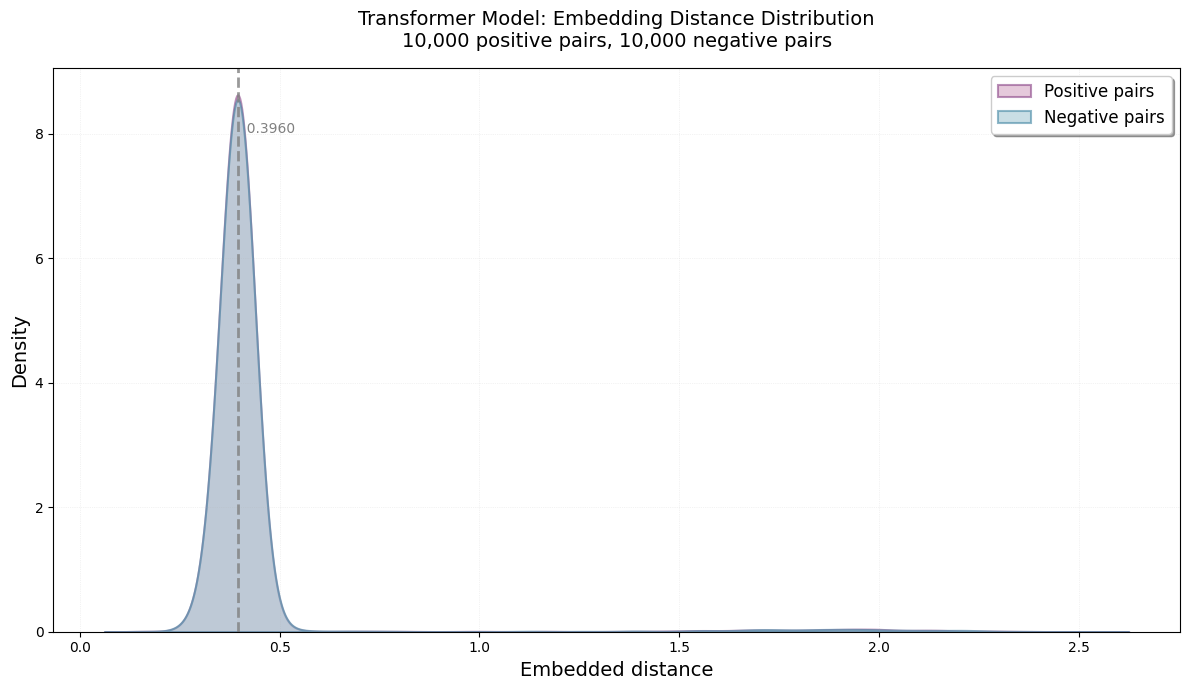

In [33]:
# Create the main distance distribution plot
fig, ax = plot_embedding_distance_distribution(
    positive_distances,
    negative_distances,
    fdr=FDR,
    save_path='../../results/embedding_distances.png',
    title=f'Transformer Model: Embedding Distance Distribution\n'
          f'{len(positive_distances):,} positive pairs, {len(negative_distances):,} negative pairs',
    figsize=(12, 7)
)

plt.show()

### 6.2 ROC Curve

ROC curve saved to: ../../results/roc_curve.png


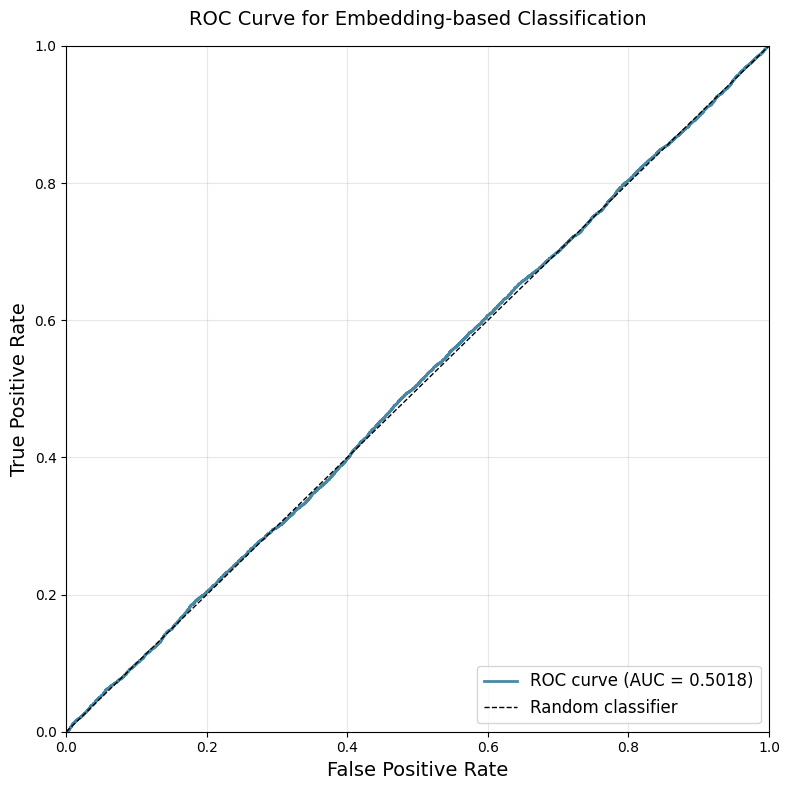


AUC Score: 0.5018


In [34]:
# Create ROC curve
fig, ax, auc_score = plot_roc_curve(
    positive_distances,
    negative_distances,
    save_path='../../results/roc_curve.png'
)

plt.show()
print(f"\nAUC Score: {auc_score:.4f}")

### 6.3 Additional Analysis: Distance Histograms

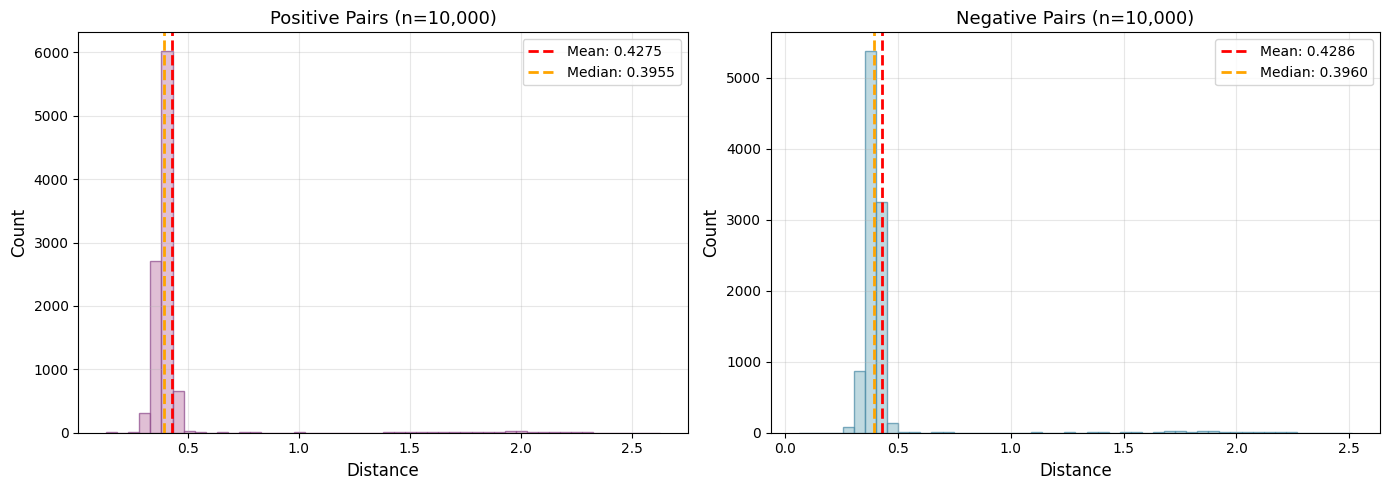

In [35]:
# Create side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Positive pairs histogram
axes[0].hist(positive_distances, bins=50, alpha=0.7, color='#d4a5c4', edgecolor='#8b4789')
axes[0].axvline(np.mean(positive_distances), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {np.mean(positive_distances):.4f}')
axes[0].axvline(np.median(positive_distances), color='orange', linestyle='--', 
                linewidth=2, label=f'Median: {np.median(positive_distances):.4f}')
axes[0].set_xlabel('Distance', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title(f'Positive Pairs (n={len(positive_distances):,})', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Negative pairs histogram
axes[1].hist(negative_distances, bins=50, alpha=0.7, color='#a5c9d4', edgecolor='#4789a5')
axes[1].axvline(np.mean(negative_distances), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {np.mean(negative_distances):.4f}')
axes[1].axvline(np.median(negative_distances), color='orange', linestyle='--', 
                linewidth=2, label=f'Median: {np.median(negative_distances):.4f}')
axes[1].set_xlabel('Distance', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title(f'Negative Pairs (n={len(negative_distances):,})', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../../results/distance_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Compute Different FDR Thresholds

In [36]:
# Try different FDR levels
fdr_levels = [0.001, 0.005, 0.01, 0.05, 0.1]

print("FDR Thresholds at different levels:")
print("="*60)
for fdr in fdr_levels:
    threshold = compute_fdr_threshold(positive_distances, negative_distances, fdr)
    print(f"FDR {fdr*100:5.1f}%: threshold = {threshold:.4f}")

FDR Thresholds at different levels:
FDR   0.1%: threshold = 0.3960
FDR   0.5%: threshold = 0.3960
FDR   1.0%: threshold = 0.3960
FDR   5.0%: threshold = 0.3960
FDR  10.0%: threshold = 0.3960


## 8. Save Results to CSV

In [37]:
# Save distances to CSV for further analysis
results_df = pd.DataFrame({
    'distance': np.concatenate([positive_distances, negative_distances]),
    'label': ['positive'] * len(positive_distances) + ['negative'] * len(negative_distances)
})

output_path = '../../results/embedding_distances.csv'
results_df.to_csv(output_path, index=False)
print(f"Results saved to {output_path}")
print(f"Total records: {len(results_df):,}")

Results saved to ../../results/embedding_distances.csv
Total records: 20,000
